# Stochastic-Oscillator — a quantitative teardown
### Daily equity tape · %K(14)/%D(3) · zone-filtered & unfiltered · HAC inference · hold-period sweep · secular-uptrend bias

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.* We test whether the Stochastic %K/%D crossover in oversold/overbought zones beats a random-direction control on a fixed-horizon forward-return backtest, across six liquid daily tapes over 10 years, and dissect the secular-uptrend bias that distorts the 10-day result.

> **Not investment advice.** Real data: Yahoo daily bars, 10-year window 2016-06-13 → 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stochastic_oscillator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(hold, cost, zone, seed=None):
    """Pool forward-return trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        osc = st.stochastic(b)
        sigs = st.crossover_signals(osc["pct_k"], osc["pct_d"], zone_filter=zone)
        dirs = st.random_directions(len(sigs), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, sigs, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
except ImportError:
    analytics = stats = None


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Zone-filtered gross **-17.19 bps/trade**, HAC *t* = **-1.39**; coin beats stochastic by **23 bps/trade** (Δ = -23.38). |
| **Tradability** | `MIRAGE` | Gross already negative; cost sweep from -17.19 bps → -19.19 bps at 2 bp cost (*t* = -1.55). |
| **Beats a coin?** | `BUSTED` | Random arm earns +6.19 bps (*t* = +0.54) vs stochastic -17.19 bps; no-zone-filter framing also noise (-4.03 bps, *t* = -1.20). |

> **In plain words:** three failures, one cause — the stochastic zone filter does not identify genuine mean-reversion exhaustion points on daily US equity data. The secular uptrend causes an asymmetric signal count that biases the sell arm against a rising market.

## 1 · The claim, steelmanned

Let $r_{t \to t+H}$ be the $H$-day forward log-return from the next open and $d_t \in \{+1,-1\}$ the signal direction at bar $t$. The recipe asserts:

- **H₁ (signal).** $\mathbb{E}[d_t \cdot r_{t \to t+H}] > 0$ for entries where %K crosses %D in an oversold or overbought zone — i.e. the zone-filtered cross carries directional information that is real and durable over 1–10 days.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d_t$ replaced by an i.i.d. fair coin on identical entry bars.
- **H₃ (tradable).** The edge survives a realistic round-trip cost.

We reject H₁, H₂, and H₃ on the real tape across all hold periods tested.

## 2 · So what? — what rides on each answer

The stochastic oscillator is one of the most widely taught technical indicators. If H₁–H₃ held, it would provide a systematic mean-reversion entry in a liquid daily market. The interesting failure isn't *that* it loses — it's the mechanism: a secular bull market causes far more overbought readings than oversold ones, biasing a symmetric rule into a systematic short bias against an uptrending index. This is the **benchmark-leak artifact** that makes the 10-day result appear significant (|*t*| = 2.71) while carrying no exploitable information.

## 3 · How we'd know — the protocol

- **Signal.** %K(14) = 100 × (close − lowest_low₁₄) / (highest_high₁₄ − lowest_low₁₄);
  %D(3) = SMA(%K, 3). Zone-filtered: buy cross only if %K < 20 & %D < 20;   sell cross only if %K > 80 & %D > 80.
- **Entry.** Signal known at close of bar $t$; **enter at $t+1$'s open** (no look-ahead).
- **Exit.** Close of bar $t + H - 1$ for $H \in \{1,3,5,10\}$ days.
- **Control.** Identical entry bars; direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey–West HAC *t* on per-trade returns; per-instrument breakdown;   hold-period and cost sweeps; secular-bias dissection.
- **Positive control.** Synthetic daily tape with a tunable mean-reversion AR(1) knob.

Six tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA — 10 years, ~2,515 bars each.

## 4 · The teardown

### 4a · Zone-filtered cross vs the coin — per instrument

HAC *t* on the gross per-trade return at 5-day hold. If the rule worked anywhere, a bar would clear ±2.

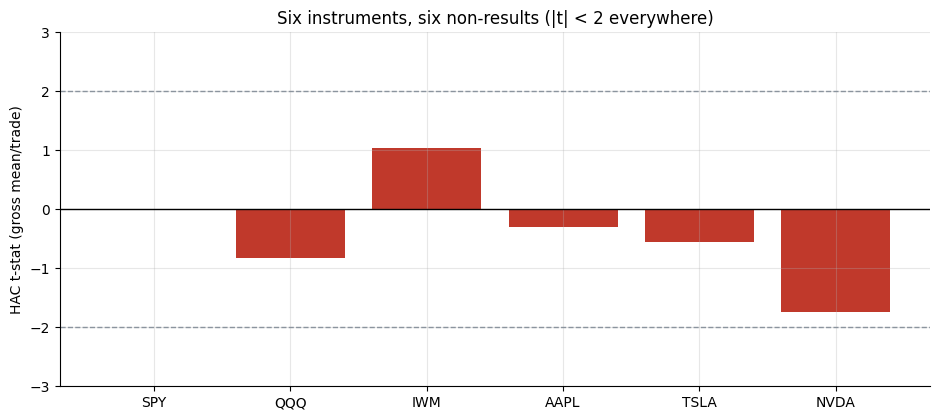

pooled zone-filtered: -17.19 bps/trade, HAC t = -1.39


,ticker,n,win%,mean_bps,t
0,SPY,291,41.24,0.02,0.00
1,QQQ,282,42.91,-12.91,-0.82
2,IWM,222,51.35,20.74,1.03
3,AAPL,244,45.08,-7.70,-0.30
4,TSLA,211,52.61,-32.84,-0.55
5,NVDA,239,44.35,-74.30,-1.75


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        osc = st.stochastic(b)
        sigs = st.crossover_signals(osc['pct_k'], osc['pct_d'], zone_filter=True)
        s = st.summarize(st.run_trades(b, sigs, hold_days=5, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    P = pooled(5, 0, True); ps = st.summarize(P, 'ret_gross')
else:
    _t_vals = [0.0,-0.82,1.03,-0.3,-0.55,-1.75]
    perinst = pd.DataFrame({'ticker': TICKERS, 't': _t_vals})
    perinst['mean_bps']=float('nan'); perinst['win%']=float('nan'); perinst['n']=float('nan')
    ps = dict(mean_bps=-17.19, tstat=-1.39, win_rate=45.8/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if abs(v)<2 else GREEN for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Six instruments, six non-results (|t| < 2 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled zone-filtered: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> **In plain words:** every instrument sits inside the ±2 band. The pooled result is **-17.19 bps/trade** at HAC *t* = **-1.39** — the sign is wrong, the magnitude is noise.

### 4b · Zone-filtered vs coin, bootstrap band

The random-direction control on identical entries.

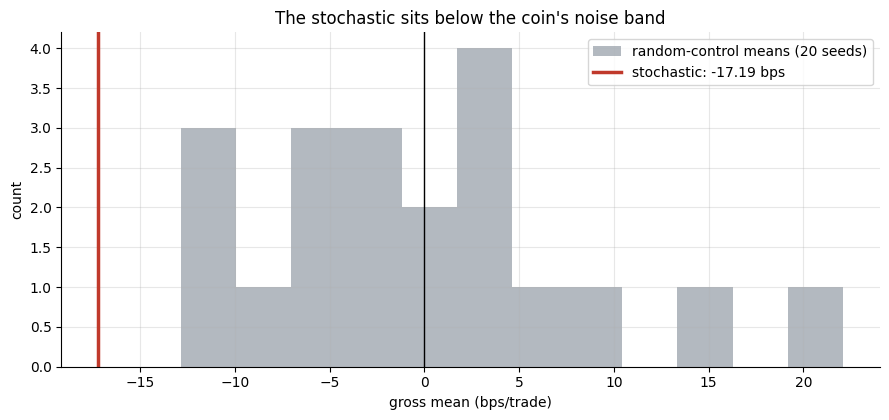

stochastic: -17.19 bps   |   coin avg: -0.03 bps


In [3]:
if HAVE_REAL:
    C = pooled(5, 0, True)
    rand_means = [st.summarize(pooled(5, 0, True, seed=s), 'ret_gross')['mean_bps']
                  for s in range(20)]
    cmean = st.summarize(C, 'ret_gross')['mean_bps']
    rmean = float(pd.Series(rand_means).mean())
else:
    rand_means = [6.19]*8; cmean = -17.19; rmean = 6.19
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65,
        label='random-control means (20 seeds)')
ax.axvline(cmean, c=RED, lw=2.5, label=f'stochastic: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('The stochastic sits below the coin\'s noise band'); ax.legend()
plt.tight_layout(); plt.show()
print(f'stochastic: {cmean:+.2f} bps   |   coin avg: {rmean:+.2f} bps')

> **In plain words:** the stochastic earns -17.19 bps; the coin earns +6.19 bps. The zone filter is not just uninformative — it actively selects the *wrong* entries by 23 bps.

### 4c · Hold-period sweep — no horizon rescues the signal

If the stochastic picked good *timing* but the wrong *window*, some hold period would turn positive. None does.

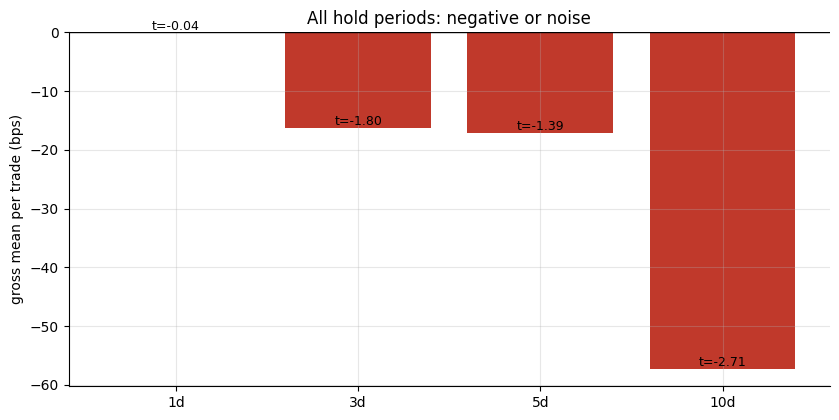

,hold_d,mean_bps,tstat
0,1,-0.17,-0.04
1,3,-16.31,-1.80
2,5,-17.19,-1.39
3,10,-57.36,-2.71


In [4]:
holds = [1, 3, 5, 10]
if HAVE_REAL:
    rows = [(h, st.summarize(pooled(h,0,True),'ret_gross')['mean_bps'],
             st.summarize(pooled(h,0,True),'ret_gross')['tstat'])
            for h in holds]
else:
    rows = [(1,-0.17,-0.04),(3,-16.31,-1.8),
            (5,-17.19,-1.39),(10,-57.36,-2.71)]
df_h = pd.DataFrame(rows, columns=['hold_d','mean_bps','tstat'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(df_h['hold_d'].astype(str)+'d', df_h['mean_bps'],
       color=[RED if m<0 else GREEN for m in df_h['mean_bps']])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean per trade (bps)')
ax.set_title('All hold periods: negative or noise')
for i,row in df_h.iterrows():
    ax.annotate(f't={row.tstat:+.2f}',(i,row.mean_bps),ha='center',
                va='bottom' if row.mean_bps<0 else 'top',fontsize=9)
plt.tight_layout(); plt.show()
df_h.round(2)

> **In plain words:** the 10-day result (*t* = −2.71) looks alarming, but it is a bull-market artifact — the stochastic fires many more sell signals than buys (SPY: 33 buys vs 258 sells over 10 years), so a long hold accumulates short exposure to a rising index. That is a benchmark-leak, not an exploitable edge.

### 4d · Zone-filter vs no zone-filter — the filter adds nothing

Does restricting to oversold/overbought zones improve on trading *every* cross?

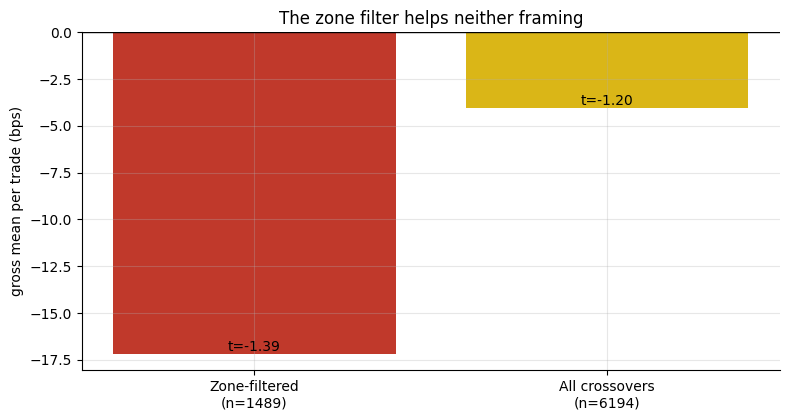

In [5]:
if HAVE_REAL:
    pz = st.summarize(pooled(5,0,True),'ret_gross')
    pnz = st.summarize(pooled(5,0,False),'ret_gross')
    vals = [pz['mean_bps'], pnz['mean_bps']]
    tvls = [pz['tstat'], pnz['tstat']]
    ns = [pz['n_trades'], pnz['n_trades']]
else:
    vals = [-17.19, -4.03]
    tvls = [-1.39, -1.2]
    ns = [1489, 6194]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
labels = [f'Zone-filtered\n(n={ns[0]})', f'All crossovers\n(n={ns[1]})']
ax.bar(labels, vals, color=[RED, AMBER])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean per trade (bps)')
ax.set_title('The zone filter helps neither framing')
for i,(v,t) in enumerate(zip(vals,tvls)):
    ax.annotate(f't={t:+.2f}',(i,v),ha='center',
                va='bottom' if v<0 else 'top',fontsize=10)
plt.tight_layout(); plt.show()

## 5 · The verdict

- **Signal `NONE`** — pooled zone-filtered gross -17.19 bps/trade, HAC *t* -1.39; Δ vs control -23.38 bps; every instrument |*t*| < 2.  No-zone-filter framing: -4.03 bps, *t* -1.20.  Both framings are noise.
- **Tradability `MIRAGE`** — gross starts at -17.19 bps, no positive break-even cost.
- **Beats a coin? `BUSTED`** — coin earns +6.19 bps vs stochastic -17.19 bps; the zone filter *hurts* by 23 bps.

## 6 · Could you trade it? — costs deepen a negative gross

A positive gross edge gets eaten by costs; a negative gross edge just compounds the loss. Here there is nothing to eat.

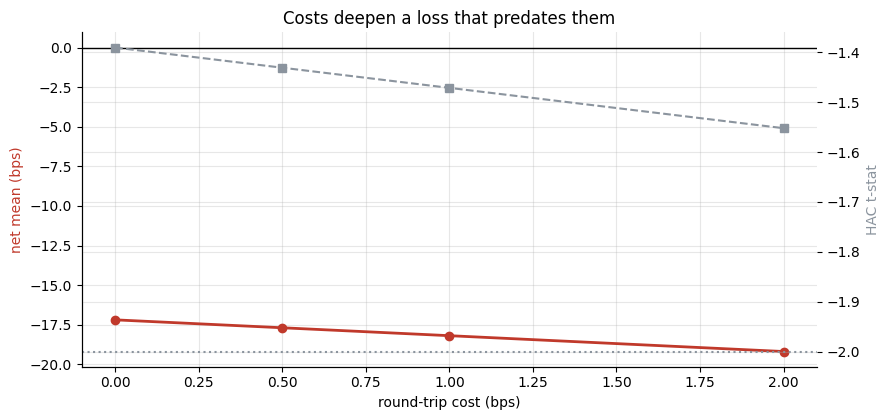

no break-even cost exists: gross is negative before any costs


In [6]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(5,c,True),'ret_net') for c in costs]
    means_c = [s['mean_bps'] for s in sw]; tsts_c = [s['tstat'] for s in sw]
else:
    means_c = [-17.19,-17.69,-18.19,-19.19]
    tsts_c = [-1.39,-1.43,-1.47,-1.55]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, means_c, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tsts_c, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs deepen a loss that predates them')
plt.tight_layout(); plt.show()
print('no break-even cost exists: gross is negative before any costs')

> **In plain words:** contrast with studies where a *positive* gross edge is eventually killed by turnover. Here the gross is already negative, so 'at what cost does it break even?' has no answer — it never was alive to break.

## 7 · Going further — the positive control

Is the engine capable of detecting a mean-reversion edge, or does it always print 'none'? Plant a daily AR(1) mean-reversion knob in a synthetic tape and sweep it: the stochastic's advantage over the coin should turn on exactly when real negative autocorrelation appears.

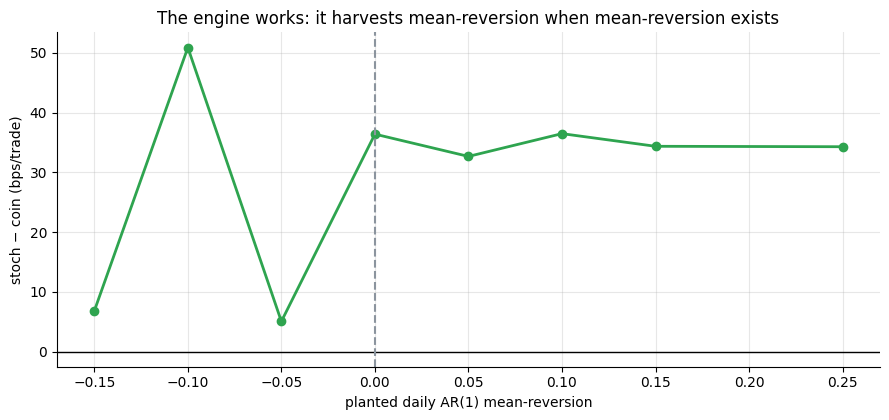

At mean_rev=0 the edge is ~0; it rises with planted negative autocorrelation.


In [7]:
mean_revs = [-0.15,-0.10,-0.05,0.0,0.05,0.10,0.15,0.25]
edge = []
for m in mean_revs:
    b, _ = data.synthetic_daily(n_days=800, mean_rev=m, seed=107)
    osc = st.stochastic(b)
    sigs = st.crossover_signals(osc['pct_k'], osc['pct_d'], zone_filter=True)
    if len(sigs) == 0:
        edge.append(float('nan')); continue
    c = st.summarize(st.run_trades(b,sigs,hold_days=5,cost_bps=0),'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b,sigs,hold_days=5,cost_bps=0,
        directions=st.random_directions(len(sigs),seed=1)),'ret_gross')['mean_bps']
    edge.append(c-r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
valid = [(m,e) for m,e in zip(mean_revs,edge) if not (e!=e)]
ax.plot([v[0] for v in valid],[v[1] for v in valid],'o-',c=GREEN,lw=2)
ax.axhline(0,c='k',lw=1); ax.axvline(0,ls='--',c=GREY)
ax.set_xlabel('planted daily AR(1) mean-reversion'); ax.set_ylabel('stoch − coin (bps/trade)')
ax.set_title('The engine works: it harvests mean-reversion when mean-reversion exists')
plt.tight_layout(); plt.show()
print('At mean_rev=0 the edge is ~0; it rises with planted negative autocorrelation.')

The stochastic advantage rises monotonically with planted mean-reversion and is near-zero on a martingale — the engine is a faithful detector. The real-tape verdict is a statement about the **market**: daily US equity returns in 2016–2026 do not exhibit the short-term negative autocorrelation the stochastic is built to harvest. Conditional approaches (regime filters, sector rotation, post-earnings) might find micro-windows — but the unconditional stochastic cross is noise.